# PRÁCTICA 2: laboratorio de árboles de decisión
##### Alumnos
- Alexandre Lorenzo Martínez
- Lucía Pérez González
- Manuel Ramallo Blanco

Na presente práctica (...)

## 2.1- Construcción dunha árbore de decisión
(...)

In [2]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
import warnings
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut
warnings.simplefilter(action='ignore', category=FutureWarning)

In [10]:
class Node:

    def __init__(self, derecho=None, izquierdo=None, atributo=None, umbral=None, valor=None):
        self.derecho = derecho
        self.izquierdo = izquierdo
        self.atributo = atributo
        self.umbral = umbral
        self.valor = valor

    def _is_leaf(self):
        return self.valor is not None


class DecisionTree:

    def  __init__(self, max_depth=None , min_samples_split=2, max_leaf_nodes=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_leaf_nodes = max_leaf_nodes
        self.n_leaf_nodes = 0

    def _is_finished(self, profundidad):
        # Compróbase si se chegou a profundidade máxima
        if self.max_depth is not None and profundidad >= self.max_depth:
            return True
        
        # Compróbase se se chegou ao número máximo de nodos folla
        if self.max_leaf_nodes is not None and self.n_leaf_nodes >= self.max_leaf_nodes:
            return True
        
        return False
    
    def _most_common_label(self, y):
        if len(y) == 0:
            return None
        return np.bincount(y).argmax()
    
    def _build_tree(self, X, y, atributos_disponibles, profundidad=0):
        if self._is_finished(profundidad) or len(y) < self.min_samples_split:
            self.n_leaf_nodes += 1
            return Node(valor=self._most_common_label(y))
        
        atributo, umbral = self._best_split(X, y, atributos_disponibles)
        if atributo is None:
            self.n_leaf_nodes += 1
            return Node(valor=self._most_common_label(y))

        X_izq, y_izq, X_der, y_der = self._create_split(X, y, atributo, umbral)
        if len(y_izq) == 0 or len(y_der) == 0:
            self.n_leaf_nodes += 1
            return Node(valor=self._most_common_label(y))

        nuevos_atributos = atributos_disponibles.copy()
        nuevos_atributos.remove(atributo)

        nodo_izquierdo = self._build_tree(X_izq, y_izq, nuevos_atributos, profundidad + 1)
        nodo_derecho = self._build_tree(X_der, y_der, nuevos_atributos, profundidad + 1)

        return Node(
            izquierdo=nodo_izquierdo,
            derecho=nodo_derecho,
            atributo=atributo,
            umbral=umbral
        )

    def _entropy(self, labels):
        if len(labels) == 0:
            return 0

        valores, counts = np.unique(labels, return_counts=True)
        proporciones = counts / len(labels)

        return -np.sum(proporciones * np.log2(proporciones))

    def _information_gain(self, X, y, atrib, entropia_anterior):
        columna = X[:, atrib]
        valores_unicos = np.unique(columna)
        #imprimir columna y valores únicos para debug
        if len(valores_unicos) == 2:
            umbral = np.mean(valores_unicos)
        else:
            umbral = np.median(columna)
            
        mask_izq = columna <= umbral
        mask_der = columna > umbral
        
        y_izq = y[mask_izq]
        y_der = y[mask_der]
            
        e_izq = self._entropy(y_izq)
        e_der = self._entropy(y_der)
        
        n_total = len(y)
        n_izq = len(y_izq)
        n_der = len(y_der)
        
        entropia_final = (n_izq / n_total) * e_izq + (n_der / n_total) * e_der
        ganancia = entropia_anterior - entropia_final

        return ganancia, umbral

    def _create_split(self, X, y, atributo, umbral):
            # Seleccionase a columna do atributo a dividir
            columna = X[:, atributo]

            # Créanse as máscaras booleanas (arrays booleanos)
            mask_izq = columna <= umbral
            mask_der = columna > umbral

            # Aplícanse as máscaras para obter os subconxuntos de datos
            X_izq = X[mask_izq]
            y_izq = y[mask_izq]

            X_der = X[mask_der]
            y_der = y[mask_der]

            return X_izq, y_izq, X_der, y_der

    def _best_split(self, X, y, atributos_disponibles):

        mejor_ganancia = -1
        mejor_atributo = None
        mejor_umbral = None

        entropia_anterior = self._entropy(y)

        for atrib in atributos_disponibles:
            ganancia, umbral = self._information_gain(X, y, atrib, entropia_anterior)

            if ganancia > mejor_ganancia:
                mejor_ganancia = ganancia
                mejor_atributo = atrib
                mejor_umbral = umbral
        
        if mejor_ganancia <= 0:
            return None, None

        return mejor_atributo, mejor_umbral

    def _traverse_tree(self, muestra):
        #Se supone que se guarda la raíz como atributo del árbol
        nodo = self.raiz

        while not nodo._is_leaf():
            if muestra[nodo.atributo] <= nodo.umbral:
                nodo = nodo.izquierdo
            else:
                nodo = nodo.derecho

        return nodo.valor

    def fit(self, X, y):
        self.n_features = X.shape[1]
        atributos = list(range(self.n_features))
        self.raiz = self._build_tree(X, y, atributos.copy())

    def predict(self, X):
        #Recorre cada muestra de X y devuelve el conjunto de predicciones
        predictions = []
        for muestra in X:
            prediction = self._traverse_tree(muestra)
            predictions.append(prediction)
        return np.array(predictions)
    
    def print_arbol(self, nodo=None, nivel=0):
        features = ["age_young", "age_pre-presbyopic", "age_presbyopic", "prescription_myope", "prescription_hypermetrope", "astigmatic_no", "astigmatic_yes", "tear_rate_reduced", "tear_rate_normal"]
        label_values = ["no lenses", "soft", "hard"]
        if nodo is None:
            nodo = self.raiz
        
        if nodo._is_leaf():
            print('|   ' * nivel + '-> Valor:', label_values[nodo.valor])
        else:
            print('|   ' * nivel + f'-> Atributo: {features[nodo.atributo]} umbral = {nodo.umbral}')
            self.print_arbol(nodo.izquierdo, nivel + 1)
            self.print_arbol(nodo.derecho, nivel + 1)

In [11]:
def preprocesado(df, label='Label'):
    # Conversión de las variables categóricas a numéricas
    df.replace({
        "Age": {"young": 0, "pre-presbyopic": 1, "presbyopic": 2},
        "Prescription": {"myope": 0, "hypermetrope": 1},
        "Astigmatic": {"no": 0, "yes": 1},
        "TearRate": {"reduced": 0, "normal": 1},
        "Label": {"no lenses": 0, "soft": 1, "hard": 2}
    }, inplace=True)
    
    # Separación de las características (X) y la variable objetivo (y)
    X = df.drop(columns=[label])
    #Converisón a variables binarias (one hot encoding)
    X = pd.get_dummies(X, columns=X.columns)

    y = df[label]
    return X.values, y.values

## 2.2- Adestramento e validación da árbore
(...)

Nesta sección usarase a árbore de decisión do paquete sklearn (DecisionTreeClassifier) para optimizar os hiperparámetros da árbore en relación ao dataset usado (lenses.csv) e usar a configuración escollida para a implementación propia da árbore. A finalidade é comparalos usando a mesma configuración e comprobar que a árbore construída é a mesma.

Para a optimización de parámetros usarase un grid de posibles valores para cada un e probaranse todas as combinacións posibles. Os parámetros e os seus posibles valores probados son os seguintes:
 - `max_leaf_nodes_range`: Número máximo de follas da árbore: [2, 3, 4, 5, 6, 8, 10]
 - `max_depth_range`: Profundidade máxima da árbore [1, 2, 3, 4, 5]
 - `min_samples_split_range`: Número mínimo de exemplos para facer unha partición [2, 3, 4, 5, 6]

Para a validación do modelo usarase o método Leave One Out (LOOV). É un método custoso temporalmente pero moi asumible tendo en conta o tamaño do dataset (24 instancias). Consiste en facer tantas iteracións como instancias, de forma que o conxunto de validación ten un só exemplo a predecir. A métrica final `accuracy` supón a porcentaxe total de instancias que foron predecidas correctamente.

In [12]:
def preprocesado(df, label='Label'):
    # Conversión de las variables categóricas a numéricas
    df.replace({
        "Age": {"young": 0, "pre-presbyopic": 1, "presbyopic": 2},
        "Prescription": {"myope": 0, "hypermetrope": 1},
        "Astigmatic": {"no": 0, "yes": 1},
        "TearRate": {"reduced": 0, "normal": 1},
        "Label": {"no lenses": 0, "soft": 1, "hard": 2}
    }, inplace=True)
    
    # Separación de las características (X) y la variable objetivo (y)
    X = df.drop(columns=[label])
    #Converisón a variables binarias (one hot encoding)
    X = pd.get_dummies(X, columns=X.columns)

    y = df[label]
    return X.values, y.values

def optimizar_arbol_decision(dataset, label='Label'):

    X,y = preprocesado(dataset, label=label)
    # Definir los rangos de los parámetros a optimizar
    max_leaf_nodes_range = [2, 3, 4, 5, 6, 8, 10]
    max_depth_range = [1, 2, 3, 4, 5]
    min_samples_split_range = [2, 3, 4, 5, 6]

    results = []

    # Iterar sobre todas las combinaciones de parámetros
    for max_leaf_nodes in max_leaf_nodes_range:
        for max_depth in max_depth_range:
            for min_samples_split in min_samples_split_range:
                # Crear el modelo con los parámetros actuales
                model = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=max_leaf_nodes,
                                               max_depth=max_depth,
                                               min_samples_split=min_samples_split)

                # Validación one leave out
                loo = LeaveOneOut()
                accuracies = []

                for train_index, test_index in loo.split(X):
                    X_train, X_test = X[train_index], X[test_index]
                    y_train, y_test = y[train_index], y[test_index]

                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    acc = accuracy_score(y_test, y_pred)
                    accuracies.append(acc)

                # Calcular la precisión promedio para esta combinación de parámetros
                avg_precision = np.mean(accuracies)

                results.append({
                    'max_leaf_nodes': max_leaf_nodes,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'precision': avg_precision
                })

    return results



In [13]:
df_train = pd.read_csv('data/lenses.csv')

X,y = preprocesado(df_train)

In [14]:
resultados = optimizar_arbol_decision(df_train)

Despois de entrenar o modelo procederase a estudiar os resultados obtidos. Na siguiente celda están impresas as combinacións que produciron os mellores resultados. Como se pode observar, hay ata 61 posibles opción que empataron na obtención do mellor resultado, cun `accuracy` do 87.5%

Esto quere dicir que para este conxunto de datos hay numerosas opcións que producirán , a priori, un resultado similar. O pequeno tamaño do coxunto é un factor que tamén inflúe en que apenas haxa diferencias. 

Polo tanto prodecedares a estudiar o impacto de cada parámetro por separado, así como combinados de 2 en 2, para ver si algún valor produce mellores resultados máis consistentemente. Nas gráficas e tablas mostradas a continuación mídese a media da `accuracy` obtida para todas as combinacións usando cada valor de cada determinado parámetro.

Por último, outro factor que se ha de ter en conta para decidir a configuración a usar é a interpretabilidade. Especialmente nun espazo de resultados tan apretado coma este é moi boa práctica optar por un modelo simple, rápido e sinxelo de entender.

In [15]:
#longitud de resultados
len(resultados)
#ordenar resultados por precisión
resultados_ordenados = sorted(resultados, key=lambda x: x['precision'], reverse=True)
#imprimir los mejores resultados
print(f"Mejores resultados: (resultados totales = {len(resultados_ordenados)})")
for resultado in resultados_ordenados[:69]:
    print(f"Índice: {resultados_ordenados.index(resultado)}, Parámetros: max_leaf_nodes={resultado['max_leaf_nodes']}, max_depth={resultado['max_depth']}, min_samples_split={resultado['min_samples_split']}, Precisión: {resultado['precision']:.4f}")

Mejores resultados: (resultados totales = 175)
Índice: 0, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=2, Precisión: 0.8750
Índice: 1, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=3, Precisión: 0.8750
Índice: 2, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=4, Precisión: 0.8750
Índice: 3, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=5, Precisión: 0.8750
Índice: 4, Parámetros: max_leaf_nodes=3, max_depth=2, min_samples_split=6, Precisión: 0.8750
Índice: 5, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=2, Precisión: 0.8750
Índice: 6, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=3, Precisión: 0.8750
Índice: 7, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=4, Precisión: 0.8750
Índice: 8, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=5, Precisión: 0.8750
Índice: 9, Parámetros: max_leaf_nodes=3, max_depth=3, min_samples_split=6, Precisión: 0.8750
Índice: 10, Parámetros:

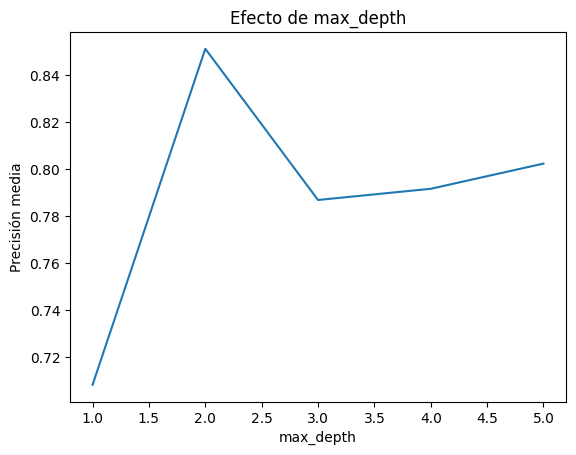

In [16]:
# Graficar resultados
df_results = pd.DataFrame(resultados)

#Visualización del efecto individual de cada hiperparámetro en la precisión

#Efecto de max_depth
depth_analysis = (
    df_results
    .groupby("max_depth")["precision"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(depth_analysis["max_depth"], depth_analysis["precision"])
plt.xlabel("max_depth")
plt.ylabel("Precisión media")
plt.title("Efecto de max_depth")
plt.show()


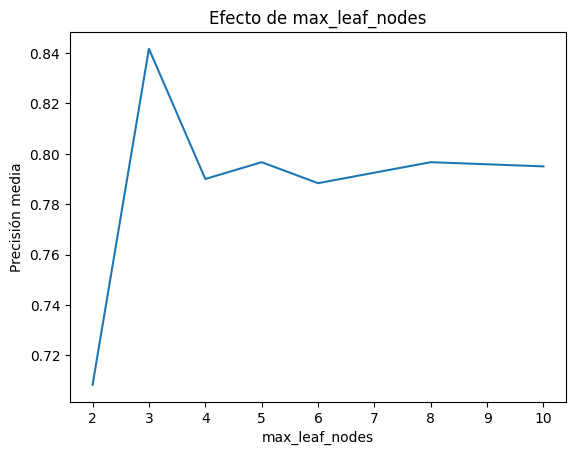

In [17]:
#Efecto de max_leaf_nodes
leaf_nodes_analysis = (
    df_results
    .groupby("max_leaf_nodes")["precision"]
    .mean()
    .reset_index()
)
plt.figure()
plt.plot(leaf_nodes_analysis["max_leaf_nodes"], leaf_nodes_analysis["precision"])
plt.xlabel("max_leaf_nodes")
plt.ylabel("Precisión media")
plt.title("Efecto de max_leaf_nodes")
plt.show()

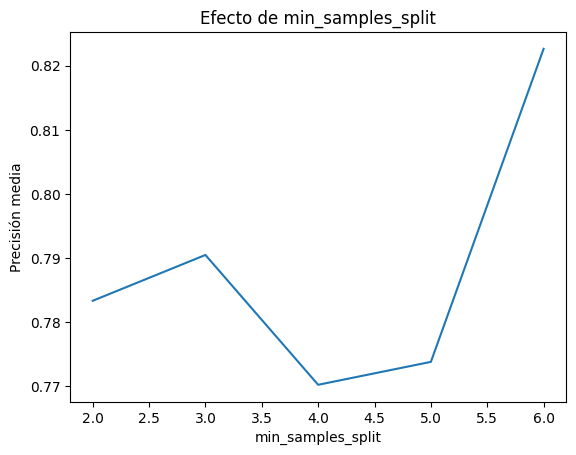

In [18]:
#Efecto de min_samples_split
min_samples_split_analysis = (
    df_results
    .groupby("min_samples_split")["precision"]
    .mean()
    .reset_index()
)
plt.figure()
plt.plot(min_samples_split_analysis["min_samples_split"], min_samples_split_analysis["precision"])
plt.xlabel("min_samples_split")
plt.ylabel("Precisión media")
plt.title("Efecto de min_samples_split")
plt.show()


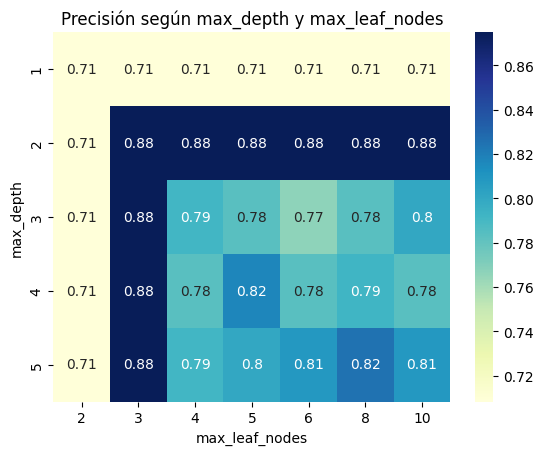

In [19]:
#Interacción entre varios parámetros

#Max_depth y max_leaf_nodes
pivot_table = df_results.pivot_table(
    values="precision",
    index="max_depth",
    columns="max_leaf_nodes",
    aggfunc="mean"
)

plt.figure()
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Precisión según max_depth y max_leaf_nodes")
plt.show()

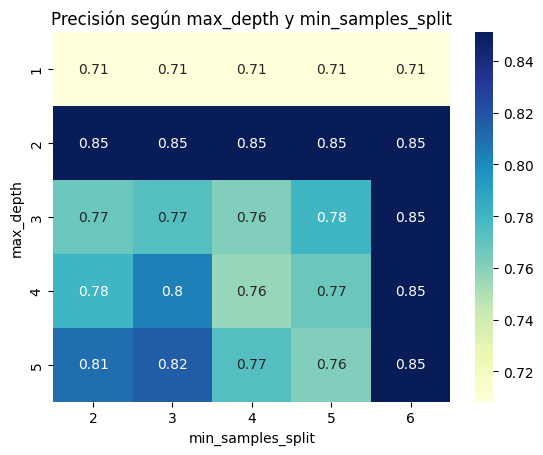

In [20]:
#Max_depth y min_samples_split
pivot_table = df_results.pivot_table(
    values="precision",
    index="max_depth",
    columns="min_samples_split",
    aggfunc="mean"
)
plt.figure()
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Precisión según max_depth y min_samples_split")
plt.show()

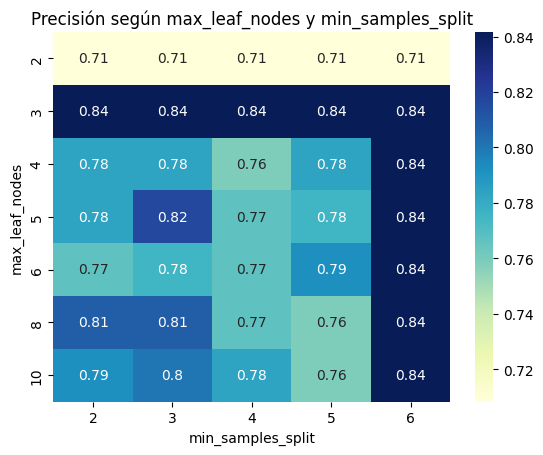

In [21]:
#Max_leaf_nodes y min_samples_split
pivot_table = df_results.pivot_table(
    values="precision",
    index="max_leaf_nodes",
    columns="min_samples_split",
    aggfunc="mean"
)
plt.figure()
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu")
plt.title("Precisión según max_leaf_nodes y min_samples_split")
plt.show()

As gráficas e tablas mostran conclusións moi claras, tanto estudiando os parámetros individualmente como en combinacións, hay un valor concreto para cada un que presenta resultados medios consistentemente mellores que o resto. Volvendo á celda anterior, pódese comprobar que efectivamente xuntándoos conseguen o `accuracy` do 87,5%. Mirando esta combinación pola parte da interpretabilidade tamén é óptima, pois reduce a complexidade da árbore ao establecer un número máximo de 2 niveles de profundidade e de 3 follas en total. 


Parámetros en cuestión a introducir no modelo propio:
##### max_leaf_nodes=3, max_depth=2, min_samples_split=6

Na celda seguinte compárase a árbore da biblioteca sklearn coa implementación da árbore da sección 2.1
Efectivamente, usando os mesmos hiperparámetros obtense unha árbore de decisión idéntica, tendo unha profundidade de 2 niveis e 3 follas en total, cada unha correspondéndose cunha das 3 posibles clases dos exemplos.

In [25]:
df_figura = pd.read_csv('data/lenses.csv')
X,y = preprocesado(df_figura)

#Entrenamiento de DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=3, max_depth=2, min_samples_split=6, random_state=0)
dt.fit(X, y)
#Convertir X a dataframe para obtener los nombres de las columnas
features = ["age_young", "age_pre-presbyopic", "age_presbyopic", "prescription_myope", "prescription_hypermetrope", "astigmatic_no", "astigmatic_yes", "tear_rate_reduced", "tear_rate_normal"]
X_df = pd.DataFrame(X, columns=features)    
text_representation = tree.export_text(
dt, feature_names=list(X_df.columns), class_names=["no lenses", "soft", "hard"])
print(f'{"-"*65}\nÁrbore de decisión DecisionTreeClassifier da biblioteca SKLearn:\n{"-"*65}')
print(text_representation)

DT = DecisionTree(max_depth=2, min_samples_split=6, max_leaf_nodes=3)
DT.fit(X, y)
print(f'{"-"*30}\nÁrbore de decisión propio:\n{"-"*30}')
DT.print_arbol()


-----------------------------------------------------------------
Árbore de decisión DecisionTreeClassifier da biblioteca SKLearn:
-----------------------------------------------------------------
|--- tear_rate_reduced <= 0.50
|   |--- astigmatic_no <= 0.50
|   |   |--- class: hard
|   |--- astigmatic_no >  0.50
|   |   |--- class: soft
|--- tear_rate_reduced >  0.50
|   |--- class: no lenses

------------------------------
Árbore de decisión propio:
------------------------------
-> Atributo: tear_rate_reduced umbral = 0.5
|   -> Atributo: astigmatic_no umbral = 0.5
|   |   -> Valor: hard
|   |   -> Valor: soft
|   -> Valor: no lenses


## 2.3- Comparación cun modelo de caixa negra: modelo neuronal (MLP)
(...)

In [31]:

def carga_e_division_datos_coches():
    # Cargamos o dataset de automóviles
    columnas = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
    df = pd.read_csv("data/car.data", header=None, names=columnas)

    # Separamos en variables predictoras (X) e variable obxetivo (y)
    X = df.drop("class", axis=1)
    y = df["class"] 

    # Convertimos a binario as variables categóricas utilizando get_dummies
    X_bin = pd.get_dummies(X)

    #Convertir a numéricas los labels
    y.replace({
        "unacc": 0,
        "acc": 1,
        "good": 2,
        "vgood": 3
    }, inplace=True)
    
    # Dividimos o dataset en entrenamento e test
    X_train, X_test, y_train, y_test = train_test_split(X_bin, y, test_size=0.3, random_state=0, stratify=y)
    return X_train.values, X_test.values, y_train.values, y_test.values

In [32]:

def adestrar_mlp(X_train, y_train):
    mlp = MLPClassifier(hidden_layer_sizes=(50,), solver= "lbfgs", learning_rate_init=0.001, max_iter=500, random_state=0)
    mlp.fit(X_train, y_train)
    return mlp

def adestrar_DTC(X_train, y_train):
    dt = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=3, max_depth=2, min_samples_split=6, random_state=0)
    dt.fit(X_train, y_train)
    return dt

def adestrar_DT_implementado(X_train, y_train):
    dt = DecisionTree(max_depth=2, min_samples_split=6, max_leaf_nodes=3)
    dt.fit(X_train, y_train)
    return dt

In [33]:
def comparar_modelos(modelos, X_test, y_test):
    resultados = []
    for nome, modelo in modelos.items():
        pred = modelo.predict(X_test)
        acc = accuracy_score(y_test, pred)
        resultados.append({"Modelo": nome, "Accuracy": acc})

        print(f"\n{nome} -- Accuracy:", acc)
    return resultados

In [34]:
# Cargamos os datos do dataset e dividímolos en conxuntos de entrenamento e test
X_coches_train, X_coches_test, y_coches_train, y_coches_test = carga_e_division_datos_coches()


# Adestramos os modelos co conxunto de adestramento
mlp = adestrar_mlp(X_coches_train, y_coches_train)
dt = adestrar_DTC(X_coches_train, y_coches_train)
DT = adestrar_DT_implementado(X_coches_train, y_coches_train)


In [35]:
# En canto estén as árbores de decisión, engadímolas ao dicionario de modelos a comparar
modelos_a_comparar = {
    "MLP": mlp,
    "DT de sklearn": dt,
    "DT implementado": DT
}

In [36]:
# Comparamos os modelos e mostramos os resultados
resultados_comparacion = comparar_modelos(modelos_a_comparar, X_coches_test, y_coches_test)

print("\nResultados comparativos:")
for resultado in resultados_comparacion:
    print(resultado)


MLP -- Accuracy: 0.9788053949903661

DT de sklearn -- Accuracy: 0.7822736030828517

DT implementado -- Accuracy: 0.7822736030828517

Resultados comparativos:
{'Modelo': 'MLP', 'Accuracy': 0.9788053949903661}
{'Modelo': 'DT de sklearn', 'Accuracy': 0.7822736030828517}
{'Modelo': 'DT implementado', 'Accuracy': 0.7822736030828517}
